In [1]:
import os 
import subprocess

In [4]:
import json
import pandas as pd
import os
df = pd.read_csv("latin_square_design.csv")
index = 20
p1 = df.iloc[0]


#研究被験者の取得
participant = f"P{index+1}"
taskSet = p1["Task Set 1"]
condition_num = int(p1["Condition 1_ConditionNum"])




#ArrangeDataを取得する
with open(f"./NumericalAnalysis/ArrangeData/PreTaskArrangement{taskSet}.json", "r", encoding="utf-8") as f:
    arrangeData = json.loads(f.read())

with open(f"./NumericalAnalysis/VOICE_LOG/{participant}/{participant}_{condition_num}.json", "r", encoding="utf-8") as f:
    voice_log = json.loads(f.read())
    
with open(f"./NumericalAnalysis/RESULTS/{participant}/{participant}_{condition_num}.json", "r", encoding="utf-8") as f:
    result_data = json.loads(f.read())

FileNotFoundError: [Errno 2] No such file or directory: 'latin_square_design.csv'

In [3]:
task_index = 11

task = voice_log[task_index]
task["taskAttempts"]




NameError: name 'voice_log' is not defined

In [5]:
import os 

os.getcwd()

'C:\\Users\\Tenma\\Desktop\\Keio\\InteractiveSmartHome\\InteractiveSmartHome\\Experiment'

In [2]:
def evaluate_all_predictions(output_data_list, arrange_data_list):
    results = []

    # arrange_data を dict に変換して素早くアクセス
    arrange_map = {
        entry["device_arrange_id"]: [dev["deviceId"] for dev in entry["devices"]]
        for entry in arrange_data_list
    }

    for output in output_data_list:
        task_id = output.get("task_id")
        predicted_ids = [d["id"] for d in output.get("selected_devices", [])]
        ground_truth_ids = arrange_map.get(task_id)

        if ground_truth_ids is None:
            print(f"[⚠️ Warning] Ground truth not found for task_id: {task_id}")
            continue

        gt_set = set(ground_truth_ids)
        pred_set = set(predicted_ids)

        true_positives = gt_set & pred_set
        false_positives = pred_set - gt_set
        false_negatives = gt_set - pred_set

        precision = len(true_positives) / len(pred_set) if pred_set else 0
        recall = len(true_positives) / len(gt_set) if gt_set else 0

        results.append({
            "task_id": task_id,
            "ground_truth": ground_truth_ids,
            "predicted": predicted_ids,
            "true_positives": list(true_positives),
            "false_positives": list(false_positives),
            "false_negatives": list(false_negatives),
            "precision": precision,
            "recall": recall
        })

    return results


In [1]:
results = evaluate_all_predictions(outputData, arrangeData)
import pprint
pprint.pprint(results)


NameError: name 'evaluate_all_predictions' is not defined

In [12]:
import pandas as pd
import re

# CSVの読み込み
condition = pd.read_csv("latin_square_design.csv")

# 変換用マッピング
replace_map = {
    "FD+SR": "空間参照だけ",
    "Pointing": "ポインティングだけ",
    "Pointing+SR": "Pointing+空間参照",
    "Label": "ラベル"
}

# Condition列だけを対象に処理
for col in condition.columns:
    if "Condition" in col:
        # ()の中の数字を取り出し、新しい列に保存
        condition[col + "_ConditionNum"] = condition[col].str.extract(r"\((\d+)\)").astype(float)

        # ()を除いた本体部分を変換
        condition[col] = condition[col].str.replace(r"\(\d+\)", "", regex=True).str.strip()
        condition[col] = condition[col].replace(replace_map)

# 結果を表示
condition.to_csv("./latin_square_design.csv", index=False)

In [8]:
import os
print("Current Working Directory:", os.getcwd())
print("Full Path:", os.path.abspath(file_path))

Current Working Directory: C:\Users\tenma\Desktop\KeioSchool\InteractiveSmartHome\InteractiveSmartHome\Experiment\NumericalAnalysis
Full Path: C:\Users\tenma\Desktop\KeioSchool\InteractiveSmartHome\InteractiveSmartHome\Experiment\NumericalAnalysis\NumericalAnalysis\VOICE_LOG\P21\P21_4.json


# Average Attempts

Friedman test: χ² = 36.985, p = 0.0000


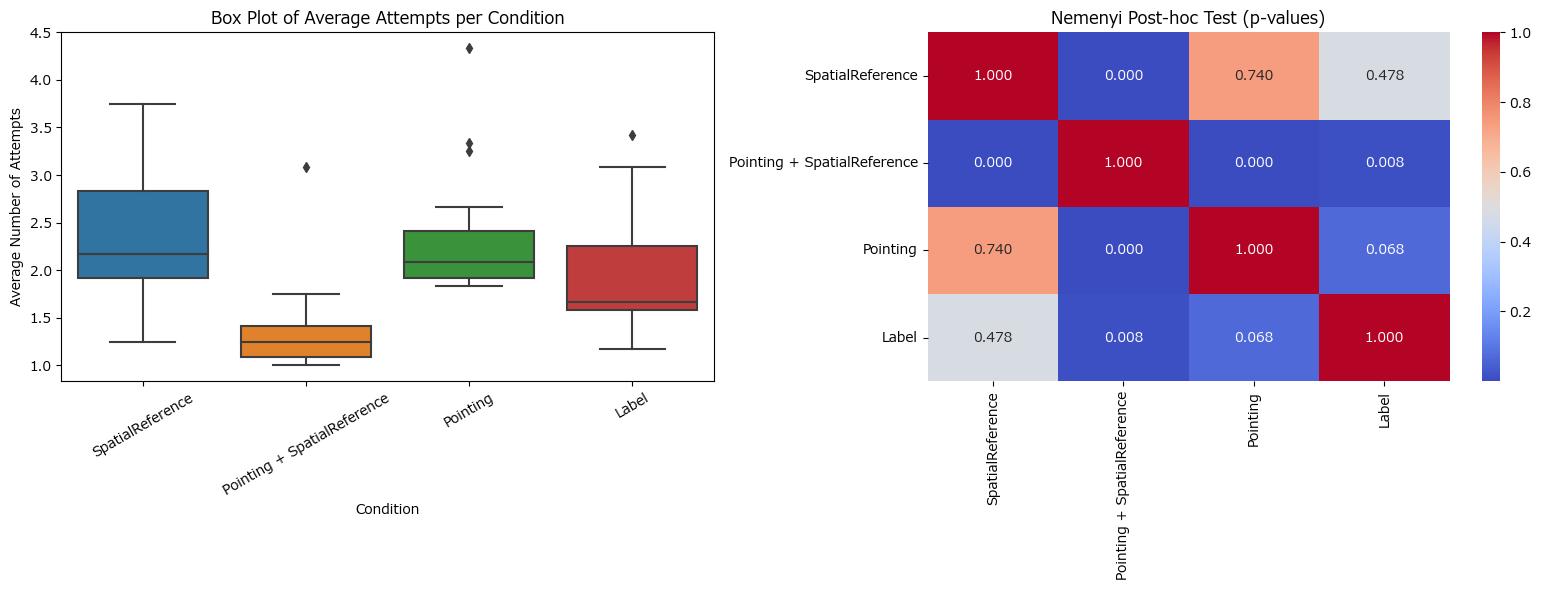

In [29]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

# ===== Load data from VOICE_LOG =====
base_dir = "./VOICE_LOG"
participants = [f"P{i}" for i in range(1, 22)]
conditions = [1, 2, 3, 4]

records = []
for participant in participants:
    for condition in conditions:
        file_path = os.path.join(base_dir, participant, f"{participant}_{condition}.json")
        if not os.path.exists(file_path):
            continue
        with open(file_path, "r", encoding="utf-8") as f:
            try:
                tasks = json.load(f)
            except json.JSONDecodeError:
                continue

        total_attempts = sum(len(task.get("taskAttempts", [])) for task in tasks)
        avg_attempts = total_attempts / len(tasks) if tasks else 0

        records.append({
            "participant": participant,
            "condition": condition,
            "average_attempts": avg_attempts
        })

df_attempts = pd.DataFrame(records)

# ===== Add condition label =====
condition_labels = {
    1: "SpatialReference",
    2: "Pointing + SpatialReference",
    3: "Pointing",
    4: "Label"
}
df_attempts["condition_label"] = df_attempts["condition"].map(condition_labels)

# ===== Pivot for Friedman test =====
df_pivot = df_attempts.pivot(index='participant', columns='condition_label', values='average_attempts')
condition_order = ["SpatialReference", "Pointing + SpatialReference", "Pointing", "Label"]
df_pivot = df_pivot[condition_order]

# ===== Friedman test =====
stat, p = friedmanchisquare(*[df_pivot[col] for col in df_pivot.columns])
print(f"Friedman test: χ² = {stat:.3f}, p = {p:.4f}")

# ===== Nemenyi test =====
nemenyi_result = sp.posthoc_nemenyi_friedman(df_pivot)

# ===== Plot: Boxplot + Heatmap side-by-side =====
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
sns.boxplot(x='condition_label', y='average_attempts', data=df_attempts, ax=axes[0])
axes[0].set_title('Box Plot of Average Attempts per Condition')
axes[0].set_xlabel('Condition')
axes[0].set_ylabel('Average Number of Attempts')
axes[0].tick_params(axis='x', rotation=30)

# Heatmap
sns.heatmap(nemenyi_result, annot=True, fmt=".3f", cmap="coolwarm", ax=axes[1])
axes[1].set_title('Nemenyi Post-hoc Test (p-values)')

plt.tight_layout()
plt.show()


Friedman test: χ² = 36.985, p = 4.634e-08

Mean Attempt Counts:
condition_label
SpatialReference               2.324
Pointing + SpatialReference    1.349
Pointing                       2.345
Label                          1.933
dtype: float64

Standard Deviations:
condition_label
SpatialReference               0.692
Pointing + SpatialReference    0.448
Pointing                       0.616
Label                          0.619
dtype: float64


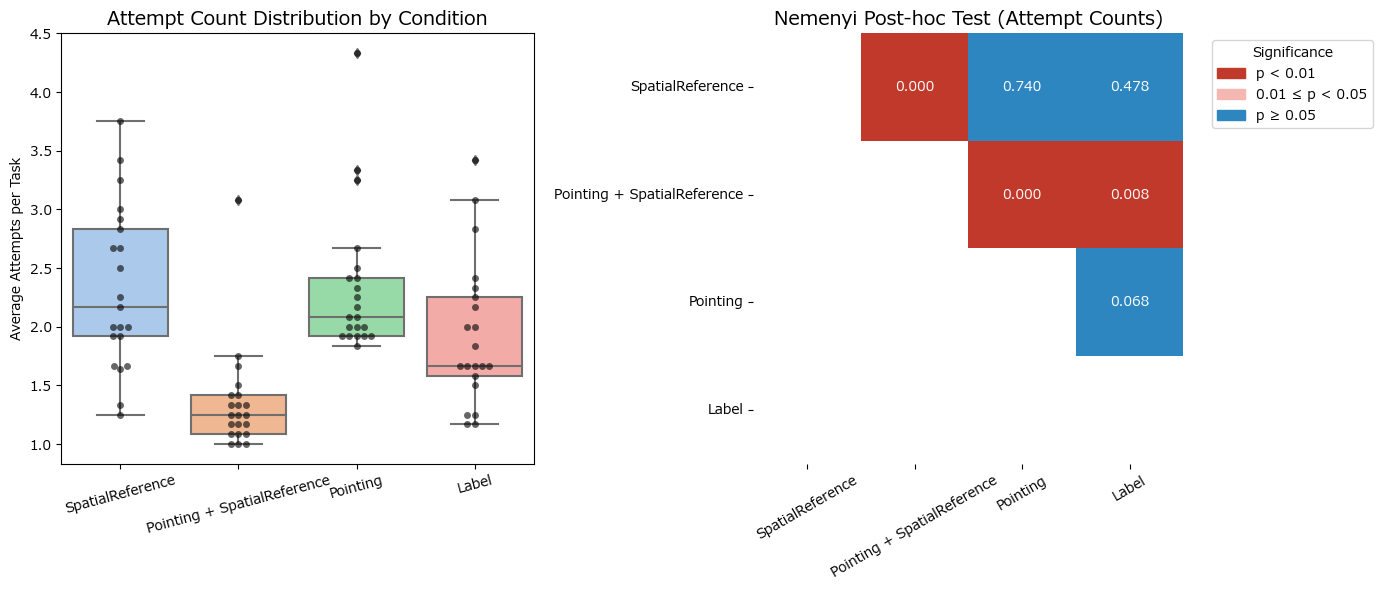

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from scipy.stats import friedmanchisquare
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# ==== 必須：df_attempts（participant, condition_label, average_attempts）がすでに存在していること ====

# 1. Wide形式に変換
condition_order = ["SpatialReference", "Pointing + SpatialReference", "Pointing", "Label"]
df_attempts_wide = df_attempts.pivot(index="participant", columns="condition_label", values="average_attempts")[condition_order]

# 2. Long形式も作る
df_attempts_long = df_attempts.copy()
df_attempts_long = df_attempts_long[df_attempts_long["condition_label"].isin(condition_order)]
df_attempts_long["condition_label"] = pd.Categorical(df_attempts_long["condition_label"], categories=condition_order, ordered=True)

# 3. Friedman test
stat, p = friedmanchisquare(*[df_attempts_wide[col] for col in condition_order])
print(f"Friedman test: χ² = {stat:.3f}, p = {p:.4g}")

# 4. Nemenyi test
nemenyi_pvals = sp.posthoc_nemenyi_friedman(df_attempts_wide)

# 5. 描画：Box + Swarm + Nemenyi heatmap（上三角だけ色）
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === 左: Box + Swarm Plot ===
sns.boxplot(ax=axes[0], data=df_attempts_long, x="condition_label", y="average_attempts", palette="pastel")
sns.swarmplot(ax=axes[0], data=df_attempts_long, x="condition_label", y="average_attempts", color='k', alpha=0.6)
axes[0].set_title("Attempt Count Distribution by Condition", fontsize=14)
axes[0].set_ylabel("Average Attempts per Task")
axes[0].set_xlabel("")
axes[0].tick_params(axis='x', rotation=15)

# === 右: Nemenyi Heatmap（上三角のみ表示） ===
colors = ['#c0392b', '#f5b7b1', '#2e86c1']  # dark red, light red, blue
boundaries = [0.0, 0.01, 0.05, 1.0]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, ncolors=len(colors))

# 下三角をマスク
mask = np.tril(np.ones_like(nemenyi_pvals, dtype=bool))

sns.heatmap(
    nemenyi_pvals,
    ax=axes[1],
    annot=True,
    fmt=".3f",
    cmap=cmap,
    norm=norm,
    mask=mask,
    square=True,
    cbar=False,

)
axes[1].set_title("Nemenyi Post-hoc Test (Attempt Counts)", fontsize=14)
axes[1].tick_params(axis='x', rotation=30)
axes[1].tick_params(axis='y', rotation=0)

# 凡例追加
legend_elements = [
    mpatches.Patch(color='#c0392b', label='p < 0.01'),
    mpatches.Patch(color='#f5b7b1', label='0.01 ≤ p < 0.05'),
    mpatches.Patch(color='#2e86c1', label='p ≥ 0.05')
]
axes[1].legend(handles=legend_elements, title="Significance", bbox_to_anchor=(1.05, 1), loc="upper left")

# 統計値
attempt_means = df_attempts_wide.mean()
attempt_sds = df_attempts_wide.std()

print("\nMean Attempt Counts:")
print(attempt_means.round(3))
print("\nStandard Deviations:")
print(attempt_sds.round(3))

# 保存・表示
plt.tight_layout()
plt.savefig("Attempt_Box_Nemenyi.png")
plt.show()


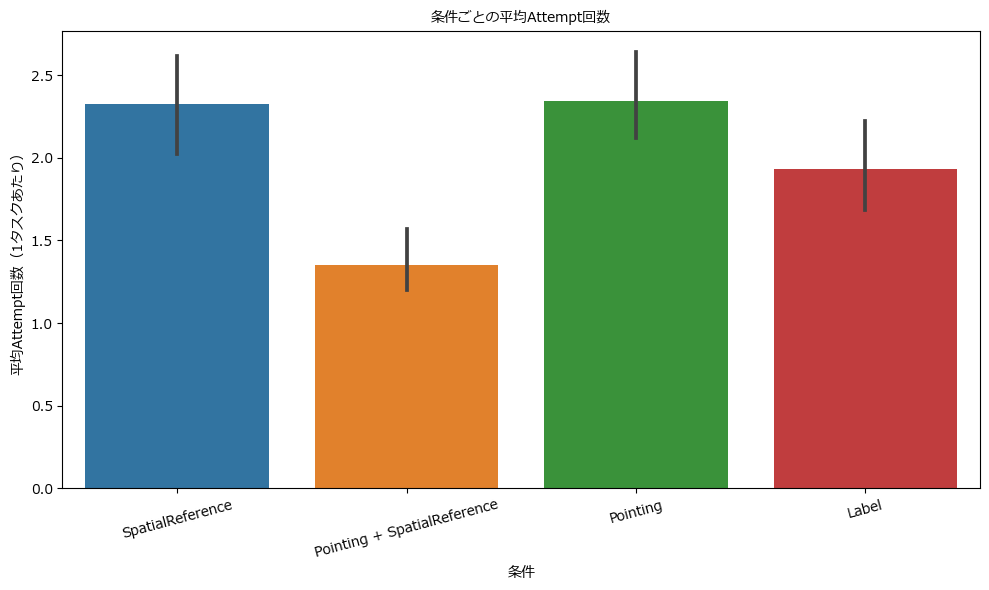

In [21]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import seaborn as sns
import pandas as pd

# 明示的にMeiryoフォントを指定（Windows用）
font_path = "C:/Windows/Fonts/meiryo.ttc"
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()


df = pd.DataFrame(df_attempts)

# 条件番号をラベルに変換
condition_labels = {
    1: "SpatialReference",
    2: "Pointing + SpatialReference",
    3: "Pointing",
    4: "Label"
}
df["condition_label"] = df["condition"].map(condition_labels)

# グラフ描画
plt.figure(figsize=(10, 6))
sns.barplot(x="condition_label", y="average_attempts", data=df)
plt.title("条件ごとの平均Attempt回数", fontproperties=font_prop)
plt.xlabel("条件", fontproperties=font_prop)
plt.ylabel("平均Attempt回数（1タスクあたり）", fontproperties=font_prop)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()





In [24]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp

# あなたが作成したdf_attemptsデータフレームを想定
# この部分は変更なし
df = pd.DataFrame(df_attempts)
condition_labels = {1: "SpatialReference", 2: "Pointing + SpatialReference", 3: "Pointing", 4: "Label"}
df["condition_label"] = df["condition"].map(condition_labels)

# ----------------------------------------------------
# Step 1: 全体的な差があるか確認（フリードマン検定）
# ----------------------------------------------------
# この部分は変更なし
cond1 = df[df['condition'] == 1]['average_attempts']
cond2 = df[df['condition'] == 2]['average_attempts']
cond3 = df[df['condition'] == 3]['average_attempts']
cond4 = df[df['condition'] == 4]['average_attempts']

statistic, p_value = stats.friedmanchisquare(cond1, cond2, cond3, cond4)

print(f"Friedman Test:")
print(f"Statistic: {statistic:.4f}, p-value: {p_value:.4f}")

if p_value < 0.05:
    print("✅ p < 0.05 なので、4つの条件の間に統計的に有意な差があると言えます。")
else:
    print("❌ p >= 0.05 なので、有意な差があるとは言えません。")

# -------------------------------------------------------------------
# Step 2: どの条件間に差があるか確認（多重比較）- 修正版
# -------------------------------------------------------------------
if p_value < 0.05:
    # データをロング形式からワイド形式に変換
    df_wide = df.pivot(index='participant', 
                       columns='condition_label', 
                       values='average_attempts')

    # ワイド形式のデータフレームを使って検定を実行
    posthoc_df = sp.posthoc_wilcoxon(df_wide, p_adjust='holm')
    
    print("\nPost-hoc Test (Wilcoxon with Holm correction):")
    print("p-values:")
    # 結果を見やすくするために、小数点以下4桁で表示
    print(posthoc_df.round(4))

Friedman Test:
Statistic: 36.9853, p-value: 0.0000
✅ p < 0.05 なので、4つの条件の間に統計的に有意な差があると言えます。


ValueError: Specify correct column names using `group_col` and `val_col` args

# ElapsedTime

❌ Missing: ./NumericalAnalysis/VOICE_LOG\P12\P12_3.json


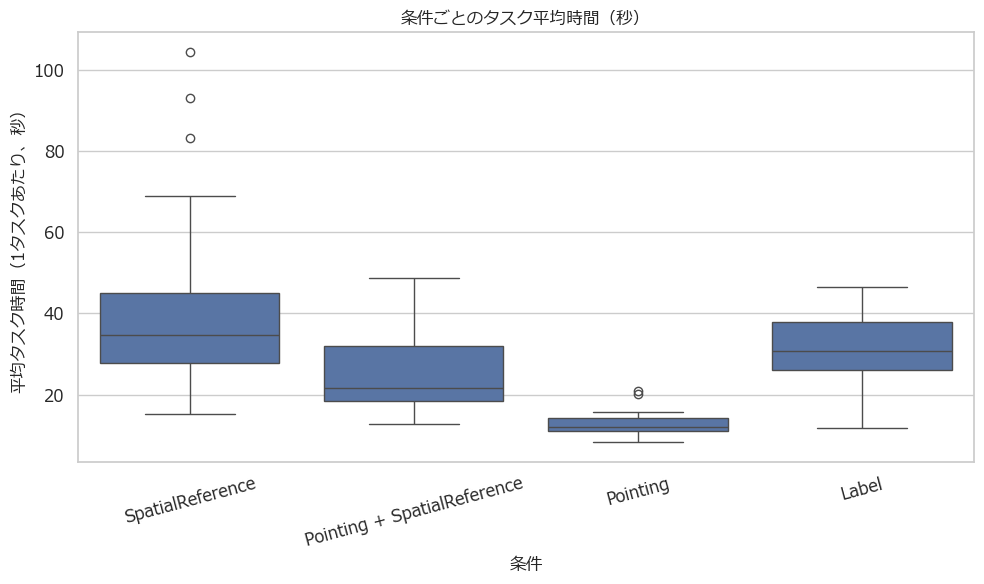

In [55]:
import os
import json
import pandas as pd

# データのパス
base_dir = "./NumericalAnalysis/VOICE_LOG"
participants = [f"P{i}" for i in range(1, 22)]
conditions = [1, 2, 3, 4]

records = []

for participant in participants:
    for condition in conditions:
        file_path = os.path.join(base_dir, participant, f"{participant}_{condition}.json")
        if not os.path.exists(file_path):
            print(f"❌ Missing: {file_path}")
            continue

        with open(file_path, "r", encoding="utf-8") as f:
            try:
                tasks = json.load(f)
            except json.JSONDecodeError:
                print(f"❌ JSON error: {file_path}")
                continue

        total_elapsed_time = 0.0
        total_task_count = 0

        for task in tasks:
            task_time = 0.0
            for attempt in task.get("taskAttempts", []):
                try:
                    task_time += float(attempt.get("taskElapsedTime", 0))
                except ValueError:
                    pass  # 変なデータは無視
            total_elapsed_time += task_time
            total_task_count += 1

        avg_task_time = total_elapsed_time / total_task_count if total_task_count > 0 else 0

        records.append({
            "participant": participant,
            "condition": condition,
            "total_time": total_elapsed_time,
            "average_task_time": avg_task_time
        })

df_time = pd.DataFrame(records)


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib import font_manager, rcParams

# 明示的に日本語フォント設定（Windows用）
font_path = "C:/Windows/Fonts/meiryo.ttc"
font_prop = font_manager.FontProperties(fname=font_path)
rcParams['font.family'] = font_prop.get_name()

# ここに df_time がすでに存在している想定
# 例: df_time = pd.DataFrame(records)

# 条件番号 → 名前に変換
condition_labels = {
    1: "SpatialReference",
    2: "Pointing + SpatialReference",
    3: "Pointing",
    4: "Label"
}
df_time["condition_label"] = df_time["condition"].map(condition_labels)

# 可視化
plt.figure(figsize=(10, 6))
sns.boxplot(x="condition_label", y="average_task_time", data=df_time)
plt.title("条件ごとのタスク平均時間（秒）", fontproperties=font_prop)
plt.xlabel("条件", fontproperties=font_prop)
plt.ylabel("平均タスク時間（1タスクあたり、秒）", fontproperties=font_prop)
plt.xticks(rotation=15, fontproperties=font_prop)
plt.yticks(fontproperties=font_prop)
plt.tight_layout()
plt.show()
